In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset=pd.read_csv("Mall_Customers.csv")
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
x = dataset.iloc[:, 3:5].values
x

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [6]:
from sklearn.cluster import MeanShift

mShift = MeanShift(bandwidth = 10).fit(x)
yMS    = mShift.fit_predict(x)


yMS

array([ 9,  6,  7,  6,  9,  6,  7, 15,  7,  6,  7, 15,  7,  6,  7,  6,  9,
        6,  9, 15,  9,  6,  7,  6, 14, 12,  9,  6, 10, 12,  7,  6,  7, 12,
       14, 12, 14,  6, 10, 12, 10, 12, 10,  1, 10,  1,  1,  1, 10, 10,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  0,  1,  1,  1,  1,  0,  1,  1,  0,  0,  1,
        0,  1,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  2,  3,  5,  0,  2,  4,  5,  4,  5,  0,  5,  4,  2,
        4,  5,  4,  5,  4,  2,  0,  2,  4,  2,  3,  5,  3,  2,  3,  2,  3,
        5,  3,  2,  4,  5,  4,  5,  3,  2,  4,  2,  3,  5,  3,  2,  3, 17,
        3,  5,  3,  8,  3,  8,  3,  5, 11,  8, 13,  8, 11,  8, 13,  8, 11,
       17, 11,  8, 11, 17, 23, 22, 21, 16, 20, 16, 19, 18])

In [7]:
dataset['Cluster_Group'] = yMS
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_Group
0,1,Male,19,15,39,9
1,2,Male,21,15,81,6
2,3,Female,20,16,6,7
3,4,Female,23,16,77,6
4,5,Female,31,17,40,9
...,...,...,...,...,...,...
195,196,Female,35,120,79,16
196,197,Female,45,126,28,20
197,198,Male,32,126,74,16
198,199,Male,32,137,18,19


In [8]:
mShift.cluster_centers_

array([[ 59.43902439,  47.73170732],
       [ 49.67647059,  50.94117647],
       [ 77.53846154,  90.84615385],
       [ 83.58333333,  16.5       ],
       [ 75.58333333,   8.25      ],
       [ 75.5       ,  75.16666667],
       [ 21.36363636,  75.36363636],
       [ 21.66666667,   8.88888889],
       [ 95.        ,  89.14285714],
       [ 22.42857143,  34.42857143],
       [ 35.        ,  31.33333333],
       [ 99.6       ,  18.6       ],
       [ 32.2       ,  86.8       ],
       [100.        ,  29.5       ],
       [ 33.        ,  17.75      ],
       [ 20.        ,  97.        ],
       [123.        ,  76.5       ],
       [102.        ,  68.5       ],
       [137.        ,  83.        ],
       [137.        ,  18.        ],
       [126.        ,  28.        ],
       [120.        ,  16.        ],
       [113.        ,  91.        ],
       [113.        ,   8.        ]])

/opt/anaconda3/lib/python3.13/site-packages/seaborn/regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


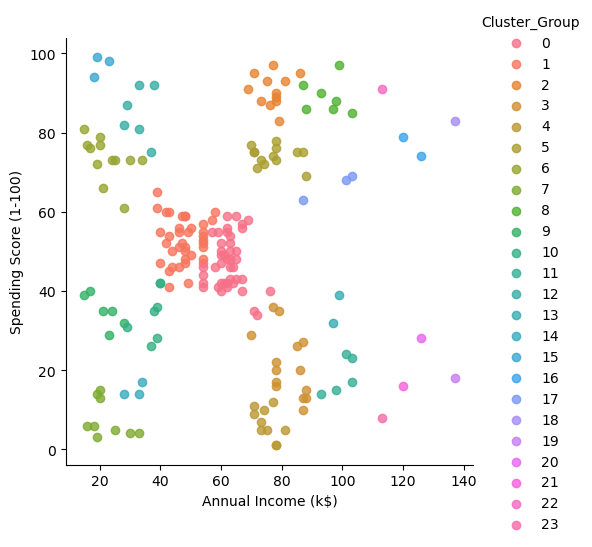

In [9]:
import seaborn as sb

facet = sb.lmplot(data = dataset, x = dataset.columns[3], y = dataset.columns[4], hue = dataset.columns[5], 
                  fit_reg = False, legend = True, legend_out = True)